In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import os
import pandas as pd

In [17]:
current_directory = os.getcwd() 

path = os.path.join(current_directory, '..', 'data', 'raw', 'base_dados_passos_magicos.xlsx')

dicionario_abas = pd.read_excel(path, sheet_name=None)

df_2022 = dicionario_abas['PEDE2022'].copy()
df_2023 = dicionario_abas['PEDE2023'].copy()
df_2024 = dicionario_abas['PEDE2024'].copy()

df_2022['origem_aba'] = 2022
df_2023['origem_aba'] = 2023
df_2024['origem_aba'] = 2024

colunas_finais = {
    'IDA': 'indicador_desempenho_academico',
    'IEG': 'indicador_engajamento',
    'IPS': 'indicador_psicossocial',
    'IAA': 'indicador_autoavaliacao'
}

df_2022 = df_2022.rename(columns=colunas_finais)
df_2023 = df_2023.rename(columns=colunas_finais)
df_2024 = df_2024.rename(columns=colunas_finais)

features_kmeans = [
    'indicador_desempenho_academico',
    'indicador_engajamento',
    'indicador_psicossocial',
    'indicador_autoavaliacao'
]

df_lista = [df_2022, df_2023, df_2024]
for i in range(len(df_lista)):
    df_lista[i] = df_lista[i][features_kmeans + ['origem_aba']].dropna()

df = pd.concat(df_lista, ignore_index=True)

In [18]:
# Contando quantos alunos têm 0 no Indicador de Autoavaliação (IAA)
total_alunos = len(df)
alunos_com_zero = len(df[df['indicador_autoavaliacao'] == 0])
percentual = (alunos_com_zero / total_alunos) * 100

print(f"Total de alunos na base: {total_alunos}")
print(f"Alunos com nota 0 em Autoavaliação: {alunos_com_zero}")
print(f"Percentual de perda se deletarmos as linhas: {percentual:.2f}%")

Total de alunos na base: 2845
Alunos com nota 0 em Autoavaliação: 245
Percentual de perda se deletarmos as linhas: 8.61%


In [19]:
df = df[df['indicador_autoavaliacao'] != 0].reset_index(drop=True)

In [20]:
df[df["origem_aba"] == 2024].info()

<class 'pandas.core.frame.DataFrame'>
Index: 1034 entries, 1566 to 2599
Data columns (total 5 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   indicador_desempenho_academico  1034 non-null   float64
 1   indicador_engajamento           1034 non-null   float64
 2   indicador_psicossocial          1034 non-null   float64
 3   indicador_autoavaliacao         1034 non-null   float64
 4   origem_aba                      1034 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 48.5 KB


In [15]:
df["origem_aba"] = df["origem_aba"] = "2024"

In [24]:
df_eda = df.copy()

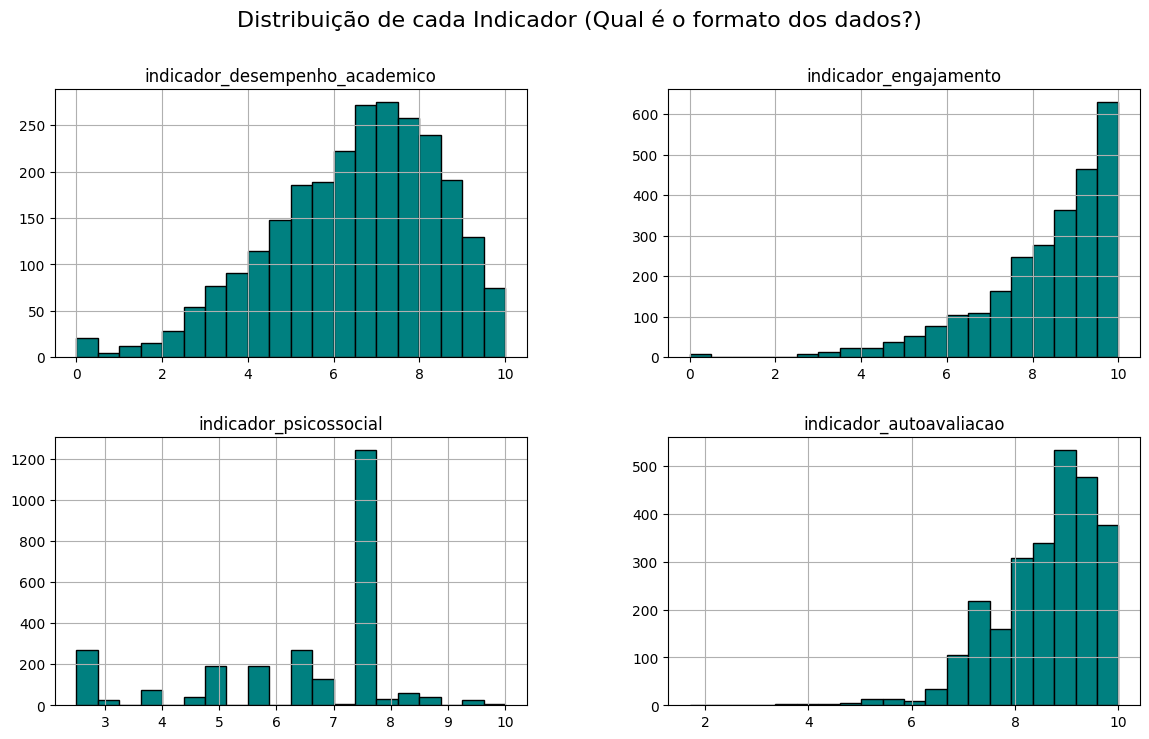

In [25]:
# 1. Distribuição Geral (Histogramas)
df_eda.drop(columns='origem_aba').hist(bins=20, figsize=(14, 8), color='teal', edgecolor='black')
plt.suptitle('Distribuição de cada Indicador (Qual é o formato dos dados?)', fontsize=16)
plt.show()

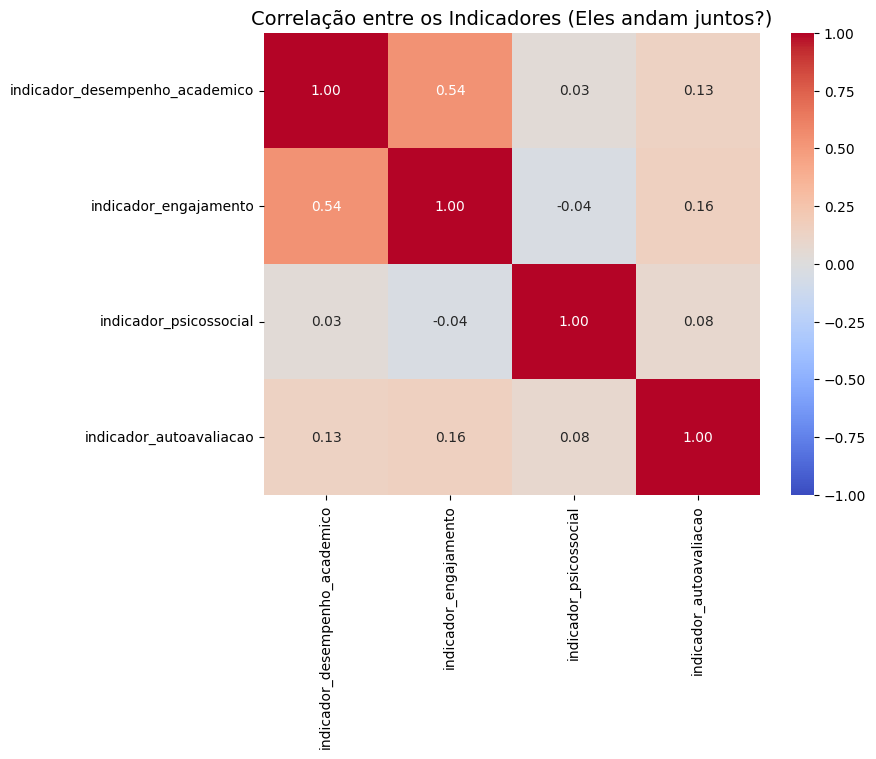

In [26]:
# 2. Matriz de Correlação (Heatmap)
plt.figure(figsize=(8, 6))
correlacao = df_eda.drop(columns='origem_aba').corr()
sns.heatmap(correlacao, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlação entre os Indicadores (Eles andam juntos?)', fontsize=14)
plt.show()

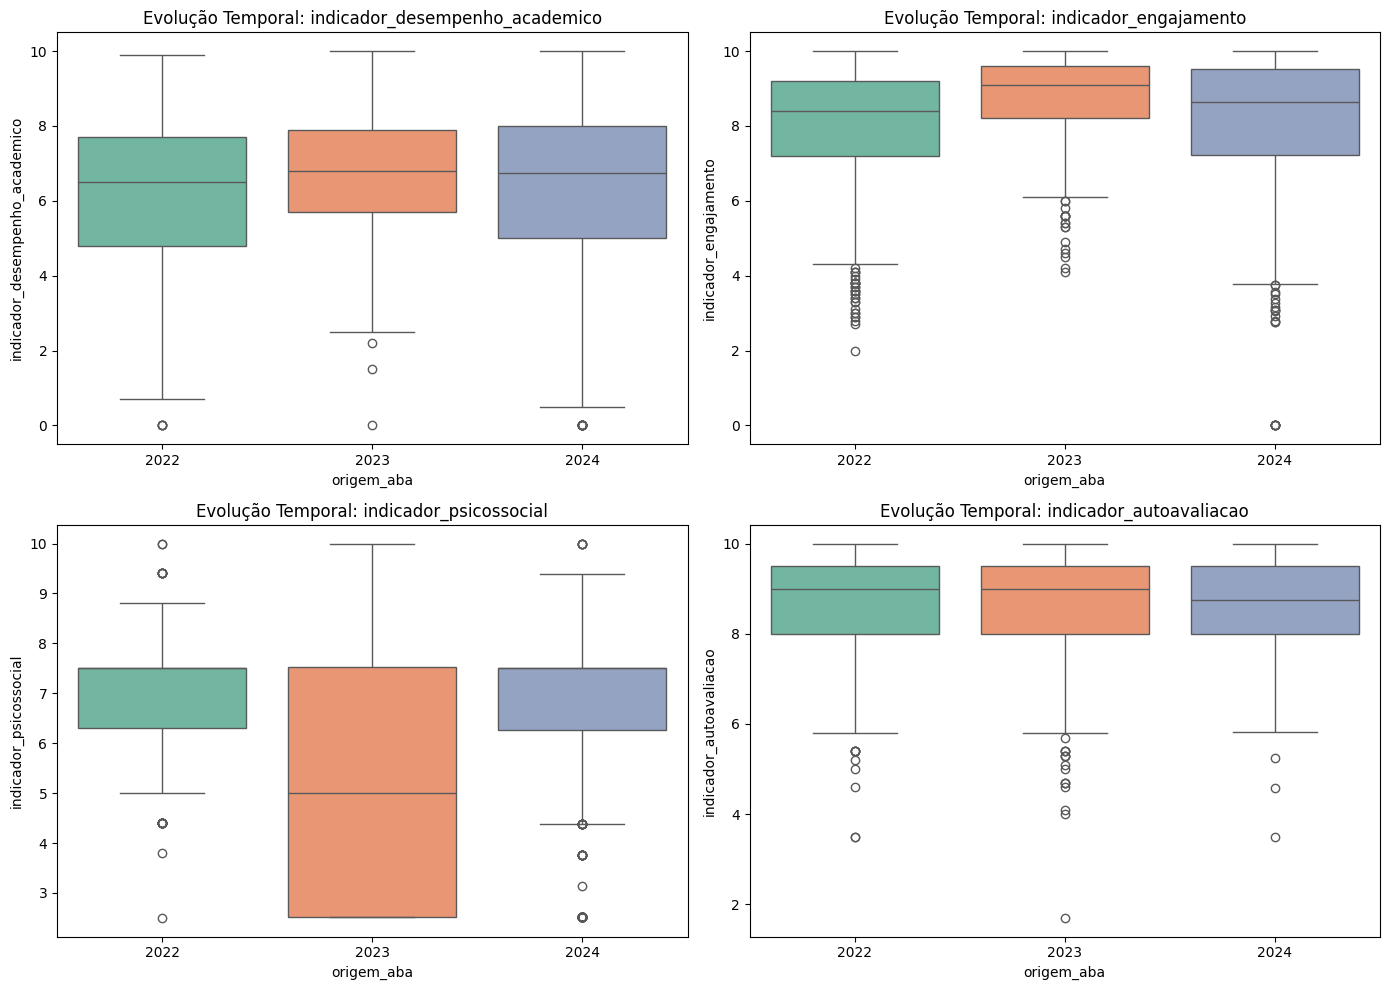

In [27]:
# 3. Evolução Temporal (Boxplots divididos pela origem_aba)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
indicadores = [
    'indicador_desempenho_academico', 'indicador_engajamento', 
    'indicador_psicossocial', 'indicador_autoavaliacao'
]

for i, col in enumerate(indicadores):
    sns.boxplot(
        data=df_eda, 
        x='origem_aba', 
        y=col, 
        ax=axes[i], 
        palette='Set2', 
        hue='origem_aba', 
        legend=False
    )
    axes[i].set_title(f'Evolução Temporal: {col}')

plt.tight_layout()
plt.show()

In [68]:
def analisar_k_ideal(df, features, k_min=2, k_max=20):
    """
    Calcula e plota a Inércia (Cotovelo) e o Score de Silhueta para diferentes valores de K.
    """
    # 1. Limpeza e Padronização
    df_limpo = df[features].dropna().copy()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_limpo)
    
    inercia = []
    silhueta = []
    k_range = range(k_min, k_max + 1)
    
    print(f"--- ANÁLISE DE K PARA AS FEATURES: {features} ---")
    
    # 2. Treinando os modelos para cada K
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
        labels = kmeans.fit_predict(X_scaled)
        
        inercia.append(kmeans.inertia_)
        score_sil = silhouette_score(X_scaled, labels)
        silhueta.append(score_sil)
        
        print(f"K = {k} | Inércia: {kmeans.inertia_:.2f} | Silhueta: {score_sil:.4f}")
        
    # 3. Plotagem dos Gráficos
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Gráfico 1: Método do Cotovelo (Inércia)
    axes[0].plot(k_range, inercia, marker='o', color='teal', linestyle='--')
    axes[0].set_title('Método do Cotovelo (Inércia)')
    axes[0].set_xlabel('Número de Clusters (K)')
    axes[0].set_ylabel('Inércia')
    axes[0].grid(True, alpha=0.3)
    
    # Gráfico 2: Score de Silhueta
    axes[1].plot(k_range, silhueta, marker='s', color='darkorange', linestyle='-')
    axes[1].set_title('Score de Silhueta (Mais alto é melhor)')
    axes[1].set_xlabel('Número de Clusters (K)')
    axes[1].set_ylabel('Score de Silhueta')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [69]:
def treinar_plotar_kmeans(df, features, k):
    """
    Treina o K-Means com o K especificado, imprime os centroides, plota o gráfico (se 2D) 
    e retorna um DataFrame com a coluna 'cluster_id'.
    """
    # 1. Preparação
    df_cluster = df[features].dropna().copy()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_cluster)
    
    # 2. Treinamento
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    df_cluster['cluster_id'] = kmeans.fit_predict(X_scaled)
    
    # Resgatando as notas originais dos centroides
    centroides_originais = scaler.inverse_transform(kmeans.cluster_centers_)
    
    # 3. Impressão das Médias (Perfis dos Clusters)
    df_centroides = pd.DataFrame(centroides_originais, columns=features)
    df_centroides.index.name = 'Cluster ID'
    print(f"\n--- MÉDIAS DOS CLUSTERS (K={k}) ---")
    print(df_centroides.round(2))
    print("-" * 40)
    
    # 4. Plotagem Automática (Apenas se forem exatamente 2 features)
    if len(features) == 2:
        plt.figure(figsize=(10, 7))
        
        # O scatter dos pontos
        sns.scatterplot(
            data=df_cluster, 
            x=features[0], 
            y=features[1], 
            hue='cluster_id', 
            palette='Set1',
            alpha=0.6
        )
        
        # O scatter dos centroides
        plt.scatter(
            centroides_originais[:, 0], 
            centroides_originais[:, 1], 
            s=300, 
            c='black', 
            marker='X',
            label='Centroides'
        )
        
        # Linhas de mediana
        plt.axvline(x=df_cluster[features[0]].median(), color='gray', linestyle='--')
        plt.axhline(y=df_cluster[features[1]].median(), color='gray', linestyle='--')
        
        plt.title(f'Clusterização: {features[0]} x {features[1]}')
        plt.xlabel(features[0])
        plt.ylabel(features[1])
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
    else:
        print(f"\n[Aviso] O gráfico de dispersão não foi gerado porque você passou {len(features)} features. O plot suporta apenas 2 features para visualização clara.")
        
    # 5. Retorna o dataframe com as predições
    return df_cluster

In [76]:

def gerar_raio_x_clusters(df, features, col_cluster='cluster_id'):
    """
    Recebe o dataframe pós-KMeans e a lista de features.
    Retorna uma tabela detalhada com o perfil (Raio-X) de cada cluster.
    """
    # Construindo o dicionário de agregações dinamicamente
    agg_dict = {
        # Conta a quantidade de alunos usando a primeira feature da lista
        'Quantidade_Alunos': (features[0], 'count') 
    }
    
    # Adiciona Média, Mínimo e Máximo para cada feature que você passou
    for f in features:
        # Usando a formatação do Pandas moderno (coluna_nova=(coluna_origem, operacao))
        agg_dict[f'Media_{f}'] = (f, 'mean')
        agg_dict[f'Min_{f}'] = (f, 'min')
        agg_dict[f'Max_{f}'] = (f, 'max')
        
    # Agrupando e calculando
    raio_x = df.groupby(col_cluster).agg(**agg_dict).round(2)
    
    print(f"\n--- RAIO-X DETALHADO ({len(raio_x)} Clusters Encontrados) ---")
    
    return raio_x

In [46]:
df_2024 = df[df['origem_aba'] == 2024].copy()


features_set1 = ['indicador_engajamento', 'indicador_desempenho_academico']

--- ANÁLISE DE K PARA AS FEATURES: ['indicador_engajamento', 'indicador_desempenho_academico'] ---
K = 2 | Inércia: 1019.08 | Silhueta: 0.4701
K = 3 | Inércia: 718.24 | Silhueta: 0.4046
K = 4 | Inércia: 548.69 | Silhueta: 0.4192
K = 5 | Inércia: 463.88 | Silhueta: 0.3582
K = 6 | Inércia: 385.49 | Silhueta: 0.3683
K = 7 | Inércia: 338.15 | Silhueta: 0.3548
K = 8 | Inércia: 295.80 | Silhueta: 0.3477


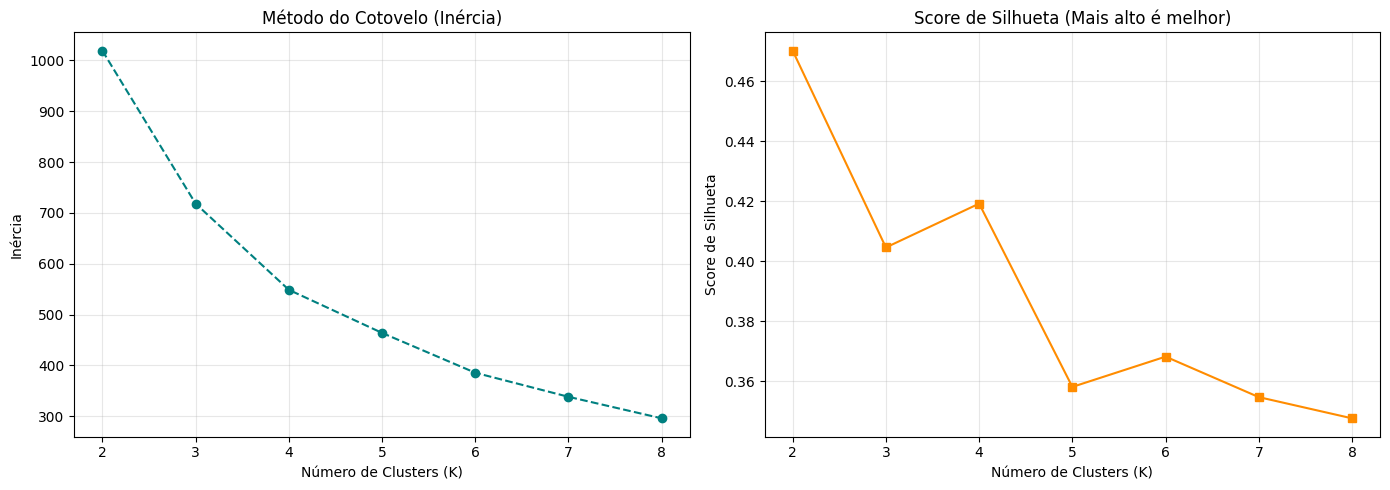

In [47]:
analisar_k_ideal(df_2024, features_set1)


--- MÉDIAS DOS CLUSTERS (K=4) ---
            indicador_engajamento  indicador_desempenho_academico
Cluster ID                                                       
0                            8.54                            4.61
1                            9.40                            8.09
2                            7.10                            7.02
3                            5.10                            3.60
----------------------------------------


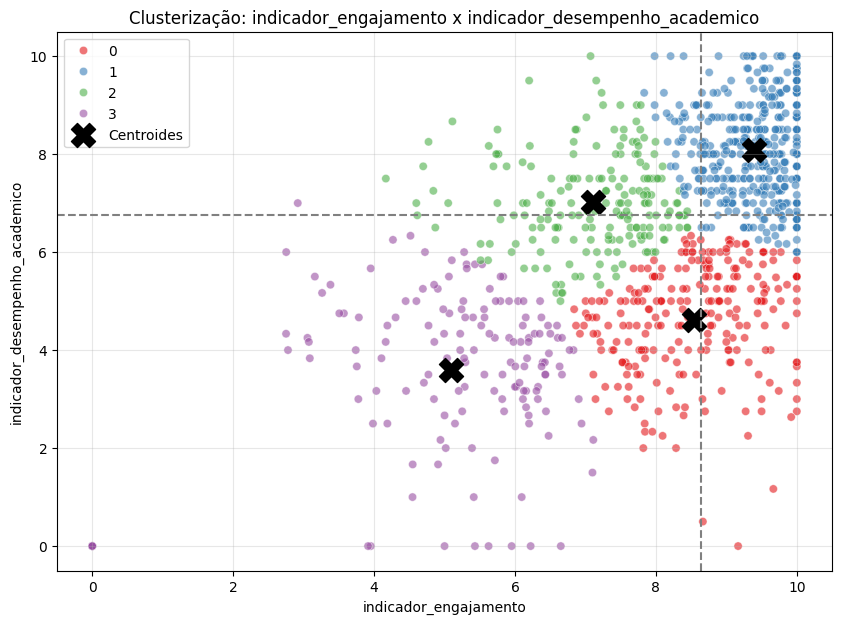

In [48]:
df_resultado_ieg_iaa = treinar_plotar_kmeans(df_2024, features_set1, k=4)

In [77]:
gerar_raio_x_clusters(df_resultado_ieg_iaa, features_set1)


--- RAIO-X DETALHADO (4 Clusters Encontrados) ---


,Quantidade_Alunos,Media_indicador_engajamento,Min_indicador_engajamento,Max_indicador_engajamento,Media_indicador_desempenho_academico,Min_indicador_desempenho_academico,Max_indicador_desempenho_academico
cluster_id,,,,,,,
0,245,8.54,6.84,10.00,4.61,0.0,6.33
1,441,9.40,7.83,10.00,8.09,6.0,10.00
2,195,7.10,4.17,8.45,7.02,5.0,10.00
3,153,5.10,0.00,7.11,3.60,0.0,7.00


--- ANÁLISE DE K PARA AS FEATURES: ['indicador_psicossocial', 'indicador_desempenho_academico'] ---
K = 2 | Inércia: 1356.62 | Silhueta: 0.3877
K = 3 | Inércia: 762.63 | Silhueta: 0.4558
K = 4 | Inércia: 610.09 | Silhueta: 0.4167
K = 5 | Inércia: 495.47 | Silhueta: 0.3949
K = 6 | Inércia: 434.53 | Silhueta: 0.3815
K = 7 | Inércia: 363.02 | Silhueta: 0.4014
K = 8 | Inércia: 290.54 | Silhueta: 0.4199


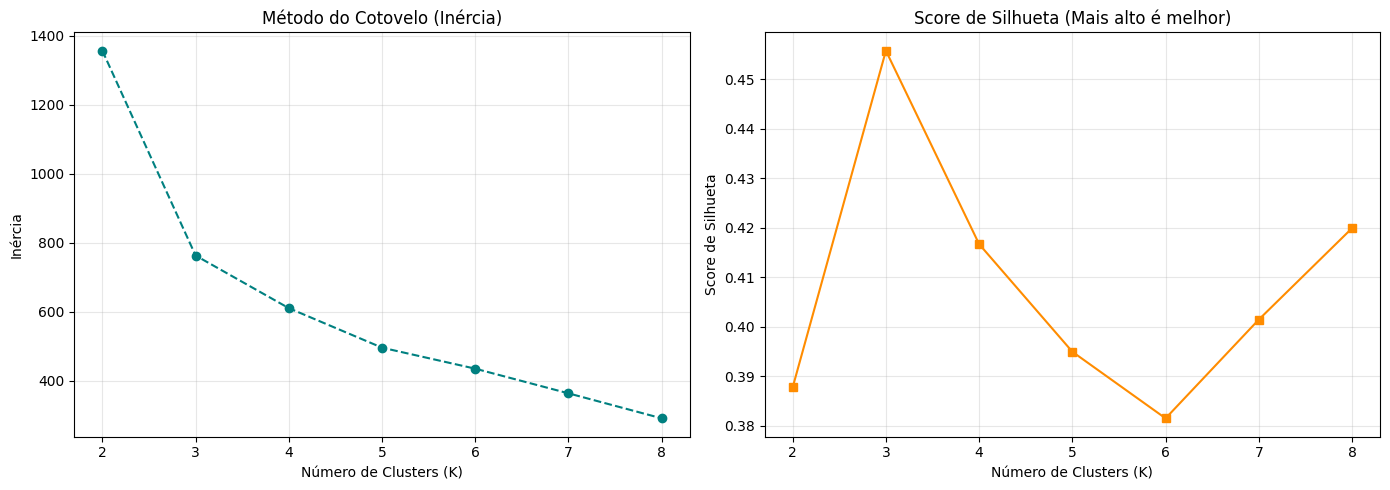

In [51]:
features_set2 = ['indicador_psicossocial', 'indicador_desempenho_academico']

analisar_k_ideal(df_2024, features_set2)


--- MÉDIAS DOS CLUSTERS (K=3) ---
            indicador_psicossocial  indicador_desempenho_academico
Cluster ID                                                        
0                             7.21                            4.13
1                             7.18                            7.75
2                             3.23                            6.22
----------------------------------------


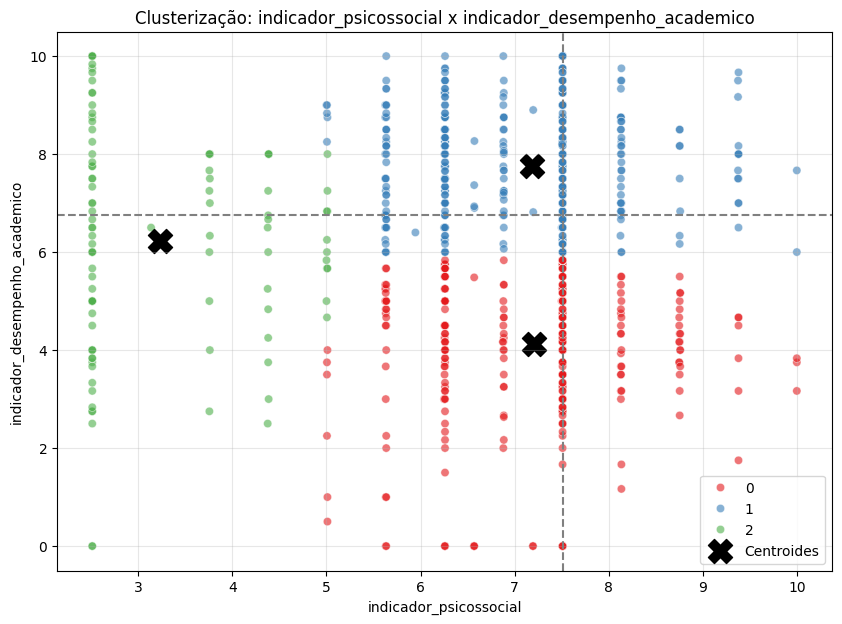

In [53]:
df_resultado_iaa_ips = treinar_plotar_kmeans(df_2024, features_set2, k=3)

In [ ]:
df_2024['dimensao_academica'] = df_2024[['indicador_desempenho_academico', 'indicador_engajamento']].mean(axis=1)
df_2024['dimensao_psicossocial'] = df_2024[['indicador_psicossocial', 'indicador_autoavaliacao']].mean(axis=1)


--- ANÁLISE DE K PARA AS FEATURES: ['dimensao_academica', 'dimensao_psicossocial'] ---
K = 2 | Inércia: 1313.58 | Silhueta: 0.3803
K = 3 | Inércia: 859.22 | Silhueta: 0.4082
K = 4 | Inércia: 690.72 | Silhueta: 0.3642
K = 5 | Inércia: 565.24 | Silhueta: 0.3555
K = 6 | Inércia: 483.80 | Silhueta: 0.3328
K = 7 | Inércia: 403.26 | Silhueta: 0.3485
K = 8 | Inércia: 349.63 | Silhueta: 0.3527
K = 9 | Inércia: 319.80 | Silhueta: 0.3324
K = 10 | Inércia: 287.42 | Silhueta: 0.3338
K = 11 | Inércia: 263.34 | Silhueta: 0.3374
K = 12 | Inércia: 238.94 | Silhueta: 0.3408
K = 13 | Inércia: 230.85 | Silhueta: 0.3231
K = 14 | Inércia: 215.89 | Silhueta: 0.3225
K = 15 | Inércia: 197.86 | Silhueta: 0.3374
K = 16 | Inércia: 181.22 | Silhueta: 0.3445
K = 17 | Inércia: 168.52 | Silhueta: 0.3450
K = 18 | Inércia: 157.37 | Silhueta: 0.3485
K = 19 | Inércia: 147.29 | Silhueta: 0.3533
K = 20 | Inércia: 139.80 | Silhueta: 0.3513


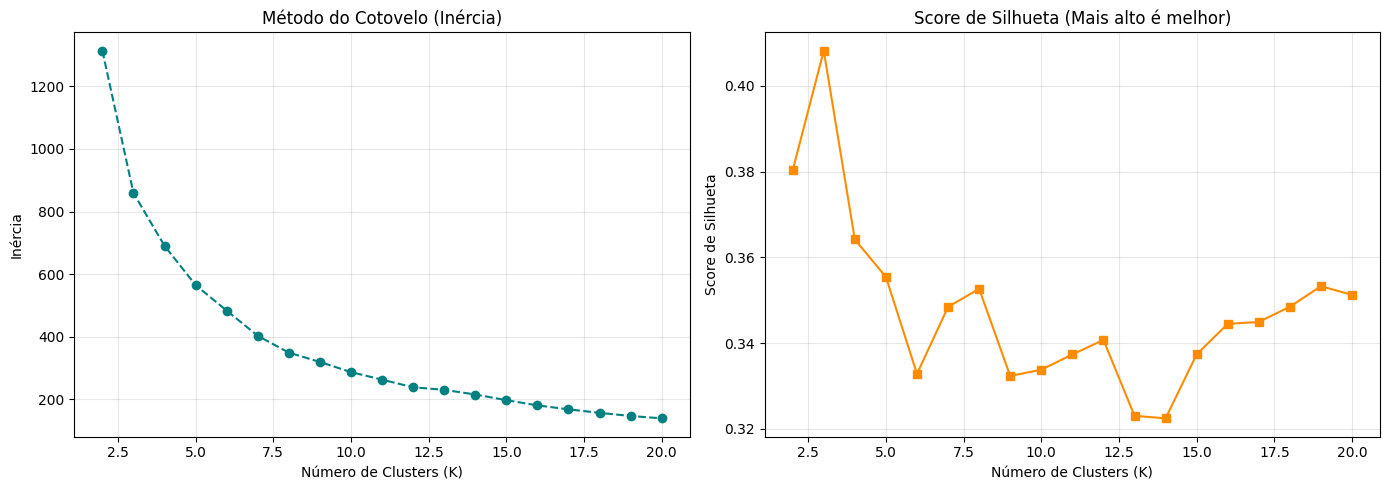

In [78]:
features_set3 = ['dimensao_academica', 'dimensao_psicossocial']

analisar_k_ideal(df_2024, features_set3)


--- MÉDIAS DOS CLUSTERS (K=8) ---
            dimensao_academica  dimensao_psicossocial
Cluster ID                                           
0                         6.19                   7.37
1                         8.76                   8.51
2                         8.35                   6.39
3                         5.53                   5.59
4                         8.64                   7.62
5                         5.16                   8.38
6                         7.14                   8.33
7                         2.86                   7.52
----------------------------------------


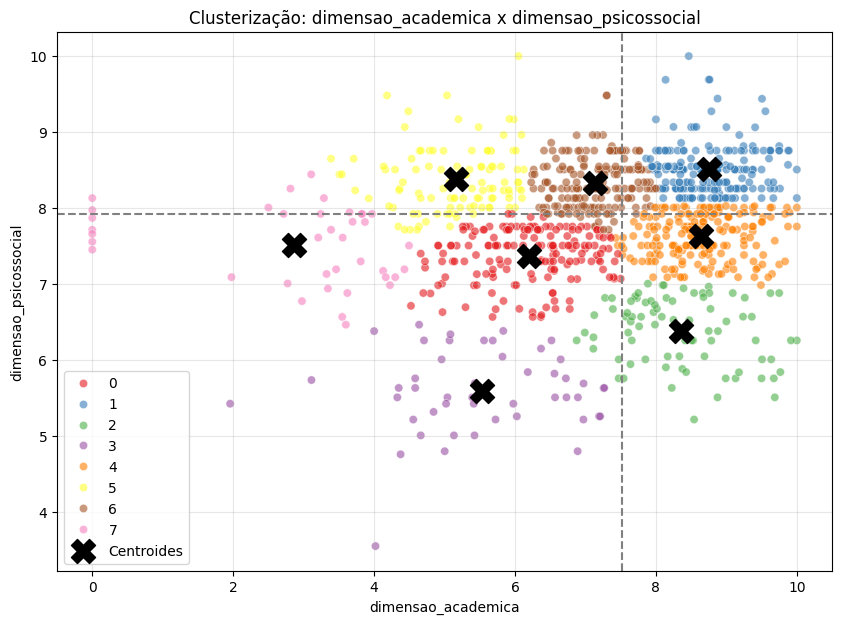

In [79]:
df_resultado_dimensoes = treinar_plotar_kmeans(df_2024, features_set3, k=8)

In [80]:
gerar_raio_x_clusters(df_resultado_dimensoes, features_set3)


--- RAIO-X DETALHADO (8 Clusters Encontrados) ---


,Quantidade_Alunos,Media_dimensao_academica,Min_dimensao_academica,Max_dimensao_academica,Media_dimensao_psicossocial,Min_dimensao_psicossocial,Max_dimensao_psicossocial
cluster_id,,,,,,,
0,168,6.20,4.52,7.50,7.37,6.56,7.92
1,203,8.76,7.86,10.00,8.51,8.13,10.00
2,81,8.35,6.88,10.00,6.39,5.21,7.00
3,48,5.53,1.96,7.27,5.59,3.55,6.46
4,204,8.64,7.43,10.00,7.62,6.98,8.03
5,106,5.16,3.39,6.12,8.38,7.71,10.00
6,186,7.14,6.23,8.00,8.34,7.71,9.48
7,38,2.86,0.00,4.50,7.52,6.46,8.44



--- MÉDIAS DOS CLUSTERS (K=3) ---
            dimensao_academica  dimensao_psicossocial
Cluster ID                                           
0                         5.38                   7.90
1                         8.31                   8.12
2                         7.12                   6.22
----------------------------------------


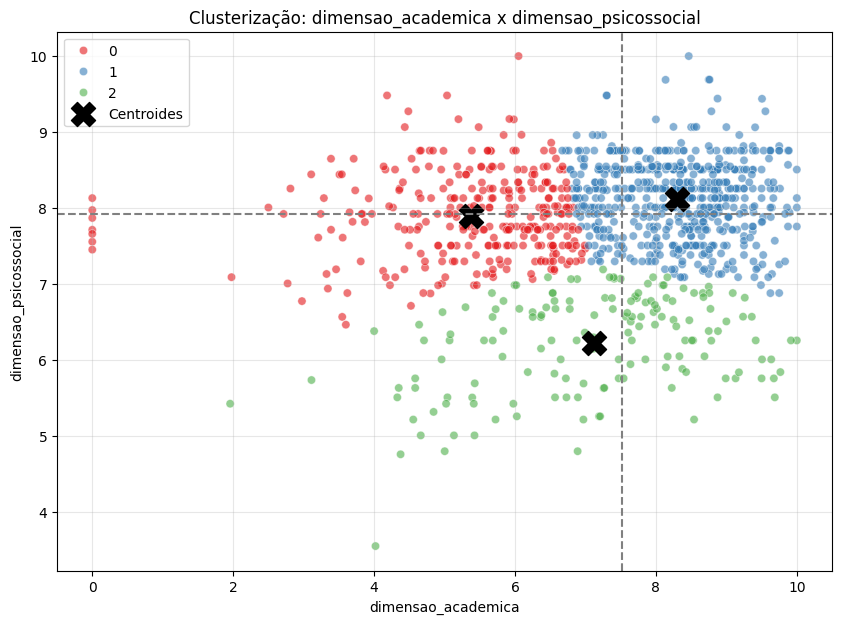

In [81]:
df_resultado_dimensoes = treinar_plotar_kmeans(df_2024, features_set3, k=3)


--- MÉDIAS DOS CLUSTERS (K=4) ---
            dimensao_academica  dimensao_psicossocial
Cluster ID                                           
0                         5.29                   7.91
1                         8.24                   8.38
2                         6.03                   5.89
3                         8.24                   7.21
----------------------------------------


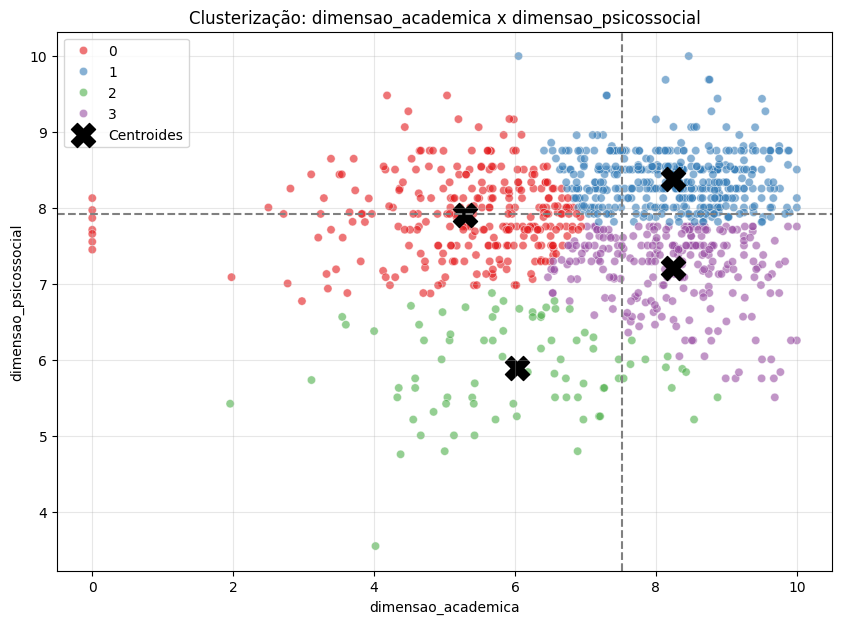

In [82]:
df_resultado_dimensoes = treinar_plotar_kmeans(df_2024, features_set3, k=4)


--- MÉDIAS DOS CLUSTERS (K=5) ---
            dimensao_academica  dimensao_psicossocial
Cluster ID                                           
0                         6.34                   7.98
1                         8.48                   8.41
2                         6.11                   5.86
3                         8.44                   7.16
4                         3.91                   7.78
----------------------------------------


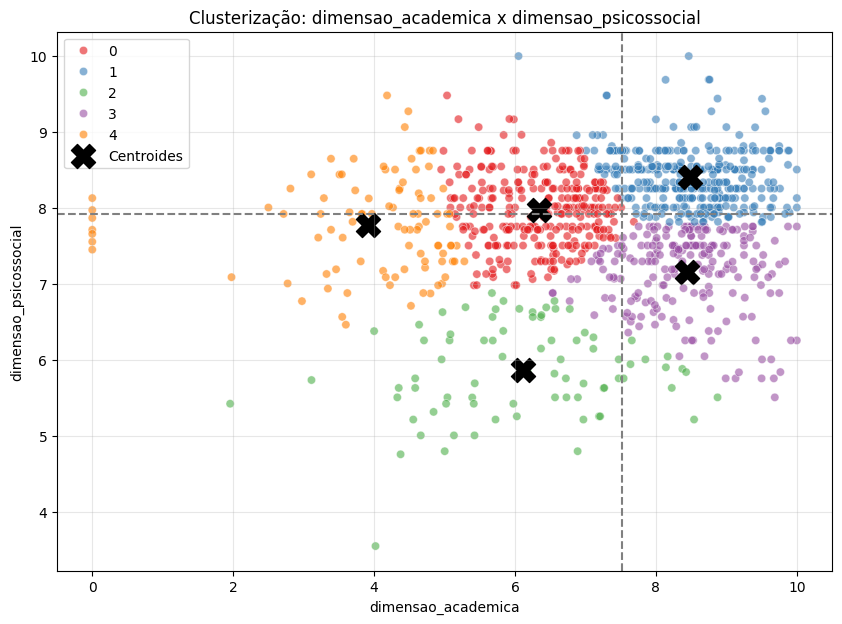

In [83]:
df_resultado_dimensoes = treinar_plotar_kmeans(df_2024, features_set3, k=5)

--- ANÁLISE DE K PARA AS FEATURES: ['dimensao_academica', 'indicador_psicossocial'] ---
K = 2 | Inércia: 1390.70 | Silhueta: 0.5233
K = 3 | Inércia: 788.29 | Silhueta: 0.4453
K = 4 | Inércia: 624.62 | Silhueta: 0.4104
K = 5 | Inércia: 536.23 | Silhueta: 0.3950
K = 6 | Inércia: 411.96 | Silhueta: 0.4270
K = 7 | Inércia: 348.06 | Silhueta: 0.4306
K = 8 | Inércia: 291.33 | Silhueta: 0.4347


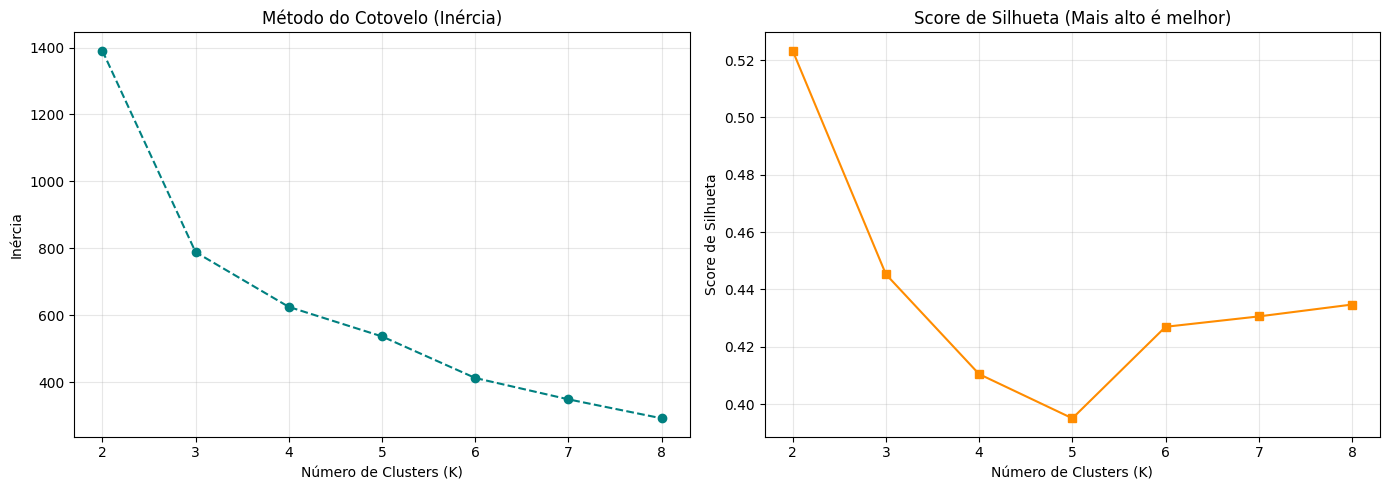

In [65]:
features_set4 = ["dimensao_academica", "indicador_psicossocial"]

analisar_k_ideal(df_2024, features_set4)


--- MÉDIAS DOS CLUSTERS (K=3) ---
            dimensao_academica  indicador_psicossocial
Cluster ID                                            
0                         5.48                    7.22
1                         6.96                    3.23
2                         8.33                    7.18
----------------------------------------


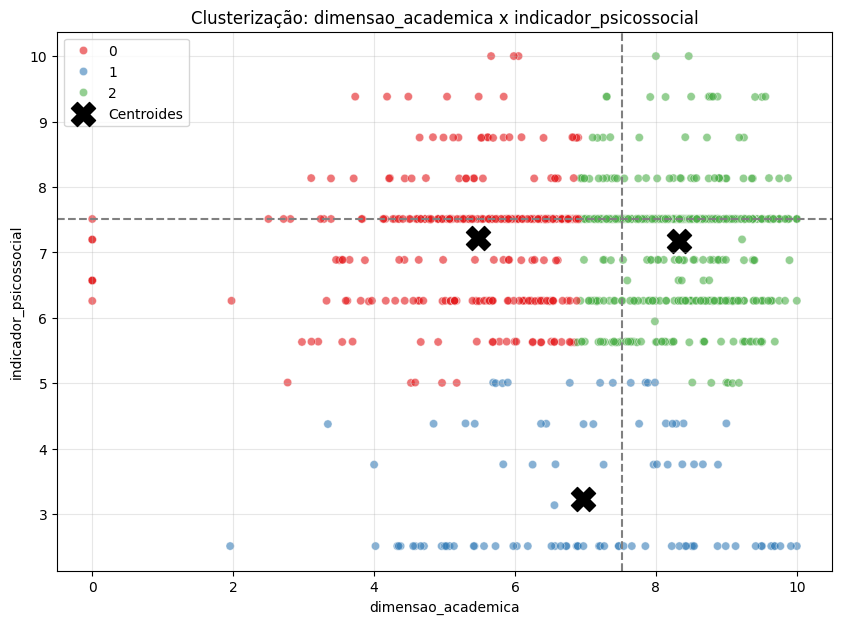

,dimensao_academica,indicador_psicossocial,cluster_id
1566,8.333333,6.2600,2
1567,8.666667,3.7600,1
1568,8.541667,3.7600,1
1569,8.375000,3.7600,1
1570,5.833333,3.7600,1
...,...,...,...
2595,7.952167,6.2600,2
2596,7.593833,6.5700,2
2597,6.276667,6.8850,0
2598,8.756333,6.5725,2


In [67]:
treinar_plotar_kmeans(df_2024, features_set4, k=3)

In [84]:
features_set3

['dimensao_academica', 'dimensao_psicossocial']

In [86]:
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch

In [ ]:
modelo_hc = AgglomerativeClustering(n_clusters=4, metric='cosine', linkage='average')

In [87]:
df_hierarquico = df_2024[features_set3].dropna().copy()

# Padronização
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_hierarquico)

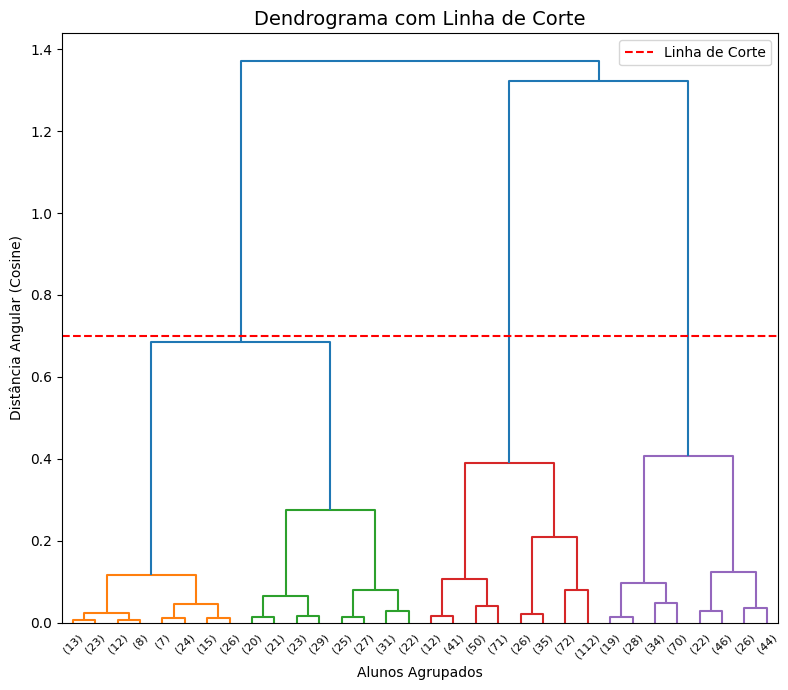

In [93]:
# Criando o dendrograma com a linha de corte
fig, ax = plt.subplots(figsize=(8, 7))

# Calculando o linkage
Z = sch.linkage(X_scaled, method='average', metric='cosine')

# Desenhando o dendrograma
sch.dendrogram(Z, ax=ax, truncate_mode='level', p=4, color_threshold=0.5)

# Adicionando a linha de corte no dendrograma
# Define a altura da linha de corte
cutoff = 0.7  # Altere esse valor conforme necessário
ax.axhline(y=cutoff, color='red', linestyle='--', label='Linha de Corte')

# Títulos e rótulos
ax.set_title('Dendrograma com Linha de Corte', fontsize=14)
ax.set_xlabel('Alunos Agrupados')
ax.set_ylabel('Distância Angular (Cosine)')
ax.legend()

plt.tight_layout()
plt.show()

In [102]:
modelo_hc_3_clusters = AgglomerativeClustering(n_clusters=3, metric='cosine', linkage='average')
df_hierarquico['cluster_id_3_clusters'] = modelo_hc_3_clusters.fit_predict(X_scaled)

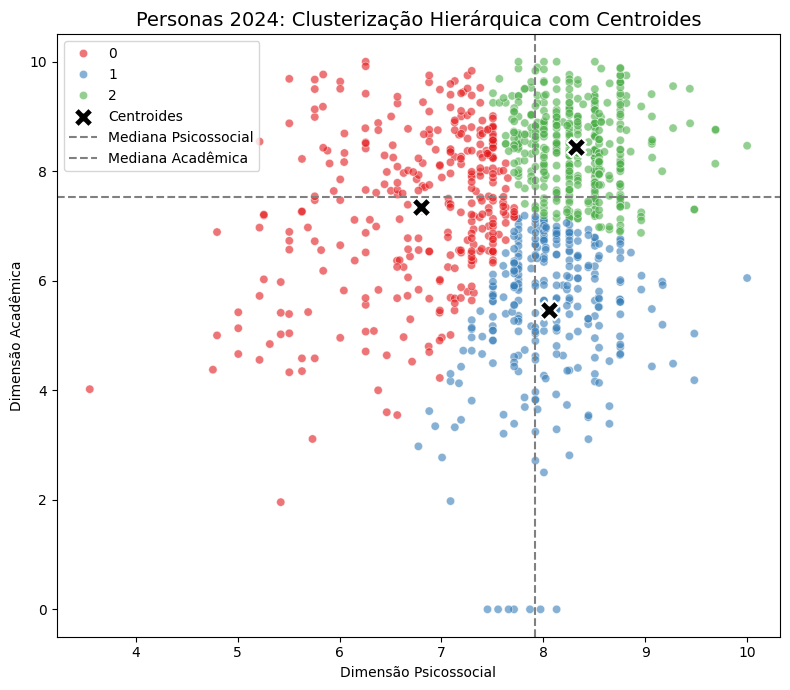

In [103]:
# Calcular os centroides (média) de cada cluster
centroides_3_clusters = df_hierarquico.groupby('cluster_id_3_clusters')[['dimensao_psicossocial', 'dimensao_academica']].mean().reset_index()

# Gráfico de dispersão com centroides
fig, ax = plt.subplots(figsize=(8, 7))

# Scatterplot para os dados
sns.scatterplot(
    data=df_hierarquico, 
    x='dimensao_psicossocial', 
    y='dimensao_academica', 
    hue='cluster_id_3_clusters', 
    palette='Set1', 
    ax=ax, 
    alpha=0.6
)

# Plotar os centroides
ax.scatter(
    centroides_3_clusters['dimensao_psicossocial'], 
    centroides_3_clusters['dimensao_academica'], 
    marker='X', 
    s=200, 
    c='black', 
    label='Centroides', 
    edgecolor='white', 
    linewidth=1.5
)

# Adicionar medianas
ax.axvline(x=df_hierarquico['dimensao_psicossocial'].median(), color='gray', linestyle='--', label='Mediana Psicossocial')
ax.axhline(y=df_hierarquico['dimensao_academica'].median(), color='gray', linestyle='--', label='Mediana Acadêmica')

# Títulos e rótulos
ax.set_title('Personas 2024: Clusterização Hierárquica com Centroides', fontsize=14)
ax.set_xlabel('Dimensão Psicossocial')
ax.set_ylabel('Dimensão Acadêmica')
ax.legend()

plt.tight_layout()
plt.show()

In [128]:
modelo_hc = AgglomerativeClustering(n_clusters=4, metric='cosine', linkage='average')
df_hierarquico['cluster_id'] = modelo_hc.fit_predict(X_scaled)

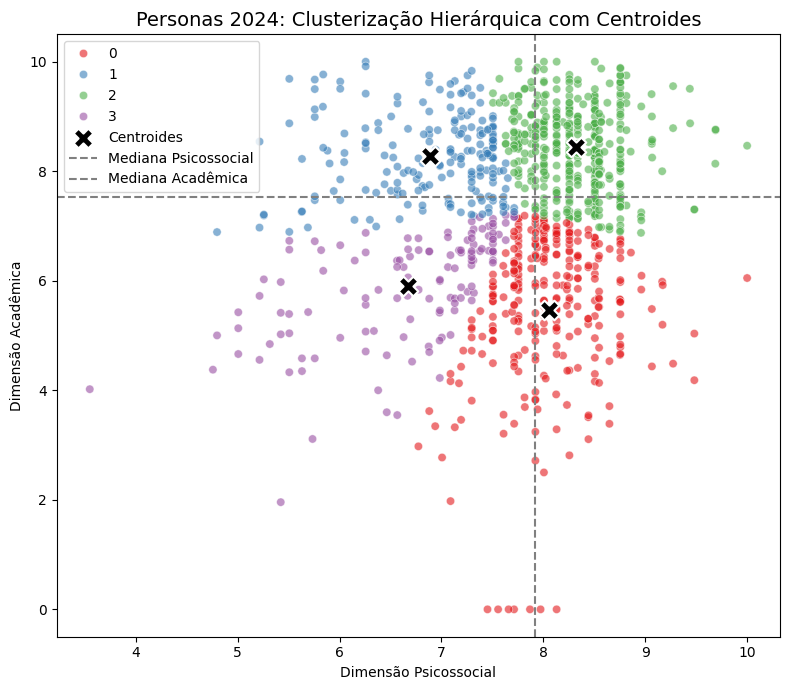

In [129]:
# Calcular os centroides (média) de cada cluster
centroides = df_hierarquico.groupby('cluster_id')[['dimensao_psicossocial', 'dimensao_academica']].mean().reset_index()

# Ajustando a transparência dos pontos, e centrando melhor os centroides
fig, ax = plt.subplots(figsize=(8, 7))

# Scatterplot com alpha ajustado para maior visibilidade
sns.scatterplot(
    data=df_hierarquico, 
    x='dimensao_psicossocial', 
    y='dimensao_academica', 
    hue='cluster_id', 
    palette='Set1', 
    ax=ax, 
    alpha=0.6,  # Menor transparência, ajuste para 0.5 ou 0.4 se necessário
    edgecolor='w',  # Ajuste da borda para facilitar a visualização
)

# Plotar os centroides (usando um tamanho de marcador maior)
ax.scatter(
    centroides['dimensao_psicossocial'], 
    centroides['dimensao_academica'], 
    marker='X', 
    s=200,  # Tamanho maior para os centroides
    c='black', 
    label='Centroides', 
    edgecolor='white', 
    linewidth=1.5
)

# Adicionar medianas
ax.axvline(x=df_hierarquico['dimensao_psicossocial'].median(), color='gray', linestyle='--', label='Mediana Psicossocial')
ax.axhline(y=df_hierarquico['dimensao_academica'].median(), color='gray', linestyle='--', label='Mediana Acadêmica')

# Ajustando a visibilidade da legenda e título
ax.set_title('Personas 2024: Clusterização Hierárquica com Centroides', fontsize=14)
ax.set_xlabel('Dimensão Psicossocial')
ax.set_ylabel('Dimensão Acadêmica')
ax.legend()

plt.tight_layout()
plt.show()

In [130]:
gerar_raio_x_clusters(df_hierarquico, features_set3)


--- RAIO-X DETALHADO (4 Clusters Encontrados) ---


,Quantidade_Alunos,Media_dimensao_academica,Min_dimensao_academica,Max_dimensao_academica,Media_dimensao_psicossocial,Min_dimensao_psicossocial,Max_dimensao_psicossocial
cluster_id,,,,,,,
0,289,5.46,0.00,7.19,8.06,6.77,10.00
1,198,8.29,6.89,10.00,6.89,4.80,7.71
2,419,8.43,6.88,10.00,8.32,7.51,10.00
3,128,5.90,1.96,7.21,6.67,3.55,7.71


In [107]:
print(gerar_raio_x_clusters(df_hierarquico, features_set3))


--- RAIO-X DETALHADO (4 Clusters Encontrados) ---
            Quantidade_Alunos  Media_dimensao_academica  \
cluster_id                                                
0                         289                      5.46   
1                         198                      8.29   
2                         419                      8.43   
3                         128                      5.90   

            Min_dimensao_academica  Max_dimensao_academica  \
cluster_id                                                   
0                             0.00                    7.19   
1                             6.89                   10.00   
2                             6.88                   10.00   
3                             1.96                    7.21   

            Media_dimensao_psicossocial  Min_dimensao_psicossocial  \
cluster_id                                                           
0                                  8.06                       6.77   
1          